In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [26]:
from utils import plot_imgs

# Data preparation
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train), X_train.shape}, Testing samples: {len(X_test), X_test.shape}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

Training samples: (160, (160, 2)), Testing samples: (40, (40, 2))


In [53]:
from models.hybrid_nn import HybridBinaryModel
# from utils import plot_decision_boundary

def qnode(inputs, weights):
    # Encodage des données classiques dans le circuit (Angle Embedding)
    qml.AngleEmbedding(inputs, wires=range(4))
    
    # Couches Variationnelles (C'est ici que le "learning" se passe)
    qml.StronglyEntanglingLayers(weights, wires=range(4))
    
    # Mesure : On mesure le premier qubit sur l'axe Z
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

# 4. Entraînement (Boucle classique PyTorch)
model = HybridBinaryModel(num_qubits=4, num_qlayers=3, qcircuit=qnode)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# loss_fn = nn.MSELoss() # Mean Squared Error
loss_fn = nn.BCEWithLogitsLoss() # Binary Cross-Entropy Loss with Logits

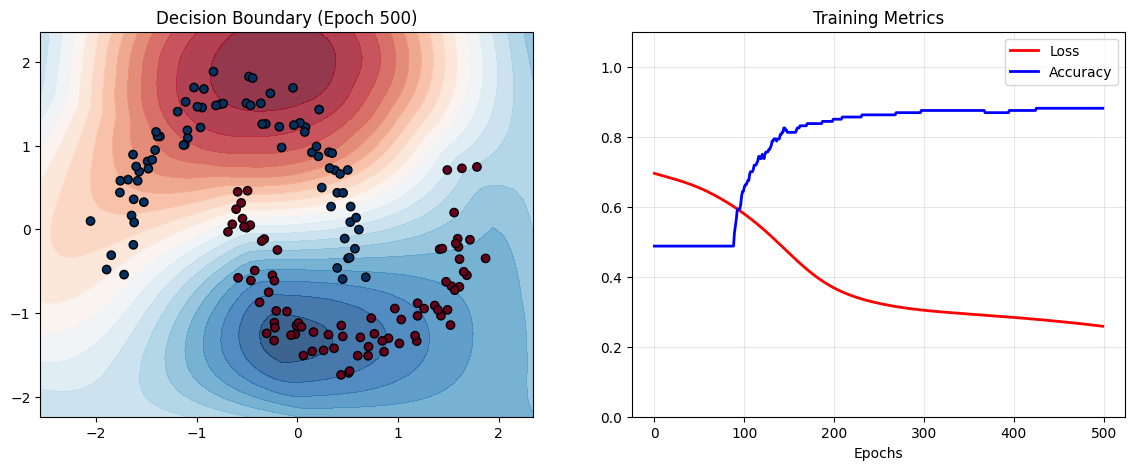

Training Completed!


In [54]:
from utils import train_and_visualize

history = train_and_visualize(model, optimizer, loss_fn, X_train, y_train, epochs=350, refresh_rate=10)

In [ ]:
from models.hybrid_nn import HybridResNet

model = HybridResNet()
print("Modèle hybride prêt. Nombre de paramètres quantiques à entraîner :", 
      sum(p.numel() for p in model.quantum_layer.parameters()))

In [2]:
# 1. Préparation des données (Le dataset "Lunes")
X, y = make_moons(n_samples=200, noise=0.1)
y = y * 2 - 1  # Changer les labels 0/1 en -1/1 pour la mesure quantique
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Convertir en Tensors PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

In [10]:
# 2. Définition du Circuit Quantique (Le "QNode")
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    # Encodage des données classiques dans le circuit (Angle Embedding)
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # Couches Variationnelles (C'est ici que le "learning" se passe)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    
    # Mesure : On mesure le premier qubit sur l'axe Z
    return qml.expval(qml.PauliZ(0))

def plot_decision_boundary(model, X, y):
    # Create a grid of points to evaluate the model
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                          np.arange(y_min, y_max, 0.01))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model(grid_points)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=50, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')


In [8]:
# 3. Création du Modèle Hybride avec PyTorch
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        # On définit la forme des poids pour le circuit quantique (3 couches)
        weight_shapes = {"weights": (3, n_qubits, 3)}
        
        # On transforme le QNode en une couche PyTorch (Magique !)
        self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
        
    def forward(self, x):
        return self.qlayer(x)

Début de l'entraînement...
Epoch 1 | Loss: 0.7861
Epoch 2 | Loss: 0.5803
Epoch 3 | Loss: 0.5087
Epoch 4 | Loss: 0.4811
Epoch 5 | Loss: 0.4738
Epoch 6 | Loss: 0.4714
Epoch 7 | Loss: 0.4641
Epoch 8 | Loss: 0.4531
Epoch 9 | Loss: 0.4443
Epoch 10 | Loss: 0.4409
Epoch 11 | Loss: 0.4411
Epoch 12 | Loss: 0.4404
Epoch 13 | Loss: 0.4367
Epoch 14 | Loss: 0.4318
Epoch 15 | Loss: 0.4287
Epoch 16 | Loss: 0.4280
Epoch 17 | Loss: 0.4278
Epoch 18 | Loss: 0.4259
Epoch 19 | Loss: 0.4224
Epoch 20 | Loss: 0.4194
Entraînement terminé !


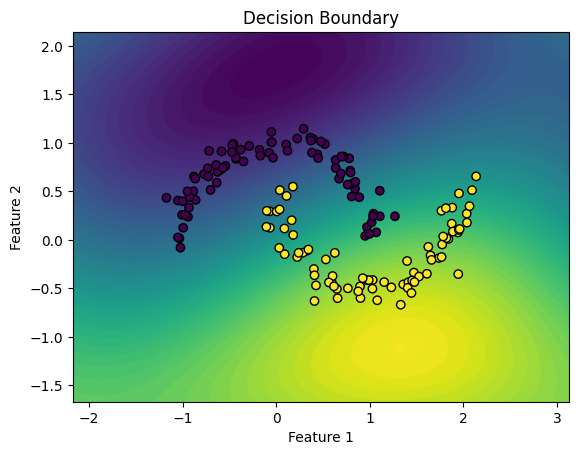

In [11]:
model = HybridModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss() # Mean Squared Error

epochs = 20
print("Début de l'entraînement...")
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = loss_fn(predictions.flatten(), y_train)
    loss.backward()
    optimizer.step()
    plot_decision_boundary(lambda x: model(torch.tensor(x, dtype=torch.float32)).detach().numpy(), X_train.numpy(), y_train.numpy())
    
    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

print("Entraînement terminé !")